# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Load Data

In [2]:
df = pd.read_csv('/content/train.csv', encoding='latin1')  # Superstore csv often needs latin1
print(df.shape)
df.head()

(9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


# Parse Date

In [3]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed', dayfirst=True)

df[['Order Date', 'Ship Date']].dtypes

,0
Order Date,datetime64[ns]
Ship Date,datetime64[ns]


# Extract Time Features

In [4]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week'] = df['Order Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Week,DayOfWeek,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,Wednesday,4,Fall
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,Wednesday,4,Fall
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,Tuesday,4,Fall
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,Tuesday,4,Fall


# Missing values, duplicates, dtypes

In [5]:
print("Missing values:\n", df.isnull().sum()[df.isnull().sum() > 0])
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDtypes:\n", df.dtypes)

Missing values:
 Postal Code    11
dtype: int64

Duplicate rows: 0

Dtypes:
 Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Year                      int32
Month                     int32
Week                     UInt32
DayOfWeek                object
Quarter                   int32
Season                   object
dtype: object


# Weekly & Monthly aggregation

In [6]:
# Monthly aggregation
monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum().reset_index()
monthly_sales.columns = ['Month', 'Total_Sales']

# Weekly aggregation
weekly_sales = df.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales'].sum().reset_index()
weekly_sales.columns = ['Week', 'Total_Sales']

print(monthly_sales.shape, weekly_sales.shape)
monthly_sales.head()

(48, 2) (209, 2)


,Month,Total_Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


# Q1: Which category generates highest revenue?

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


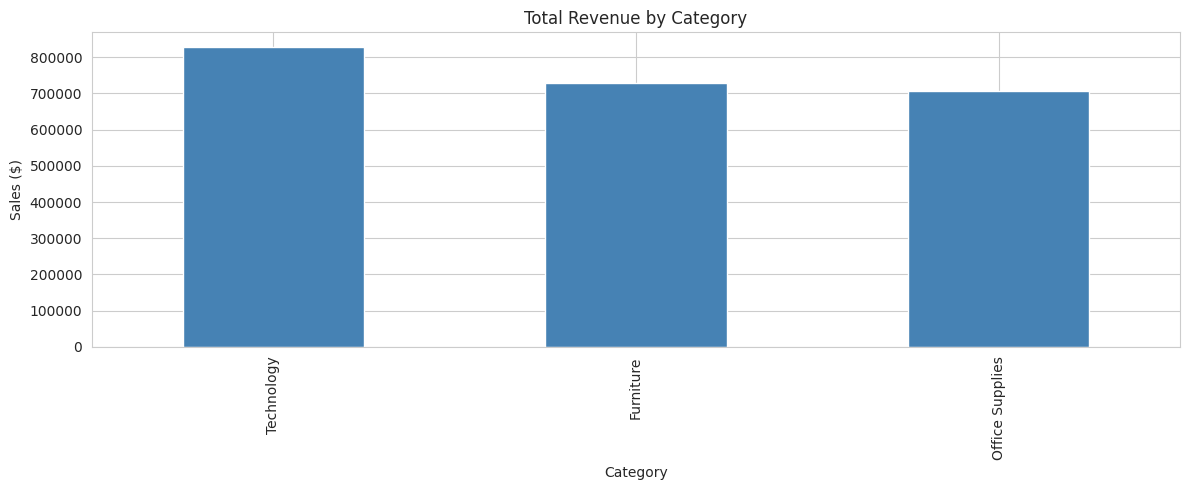

In [7]:
category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_revenue)

category_revenue.plot(kind='bar', color='steelblue', title='Total Revenue by Category')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.show()

#  Q2: Which region has most consistent growth over 4 years?

Region      Central        East        South         West
Year                                                     
2015    102920.5206  127652.819  103374.9055  145907.9630
2016    102425.1724  153225.183   70076.0825  133709.5675
2017    145673.8800  178511.538   93535.9035  182471.2285
2018    141627.3402  210129.186  122164.5675  248130.9255

Coefficient of Variation of YoY growth (lower = more consistent):
Region
East       0.099209
West       1.204981
Central    1.951359
South      3.494317
dtype: float64


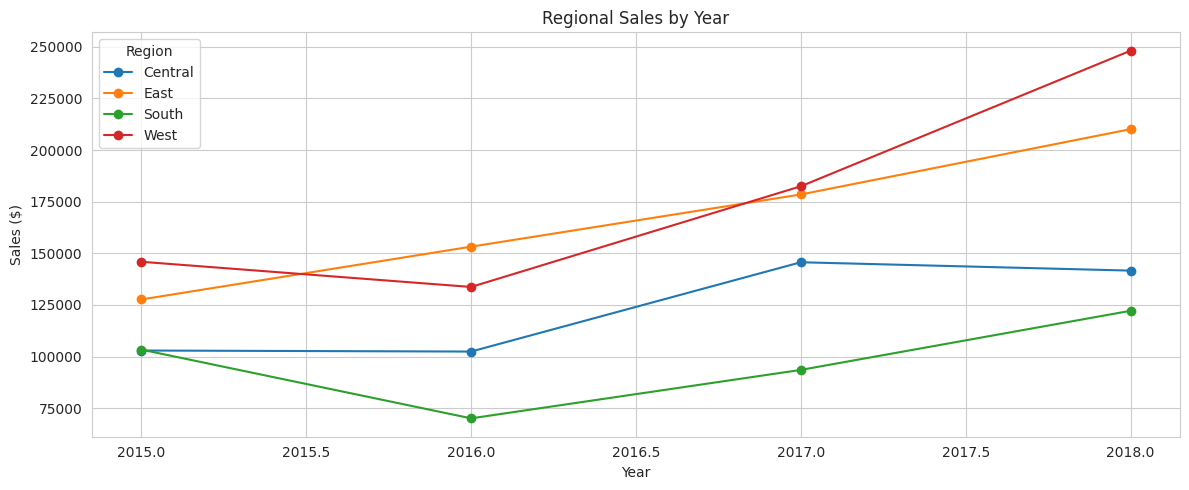

In [8]:
region_yearly = df.groupby(['Region', 'Year'])['Sales'].sum().unstack(level=0)
print(region_yearly)

# Consistency = low coefficient of variation of YoY growth
yoy_growth = region_yearly.pct_change().dropna()
consistency = yoy_growth.std() / yoy_growth.mean().abs()
print("\nCoefficient of Variation of YoY growth (lower = more consistent):")
print(consistency.sort_values())

region_yearly.plot(marker='o', title='Regional Sales by Year')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.show()

# Q3: Avg Order-to-Ship time, by region

Overall average shipping delay: 3.96 days

By region:
 Region
Central    4.065876
South      3.961202
West       3.930255
East       3.910233
Name: Ship_Delay_Days, dtype: float64


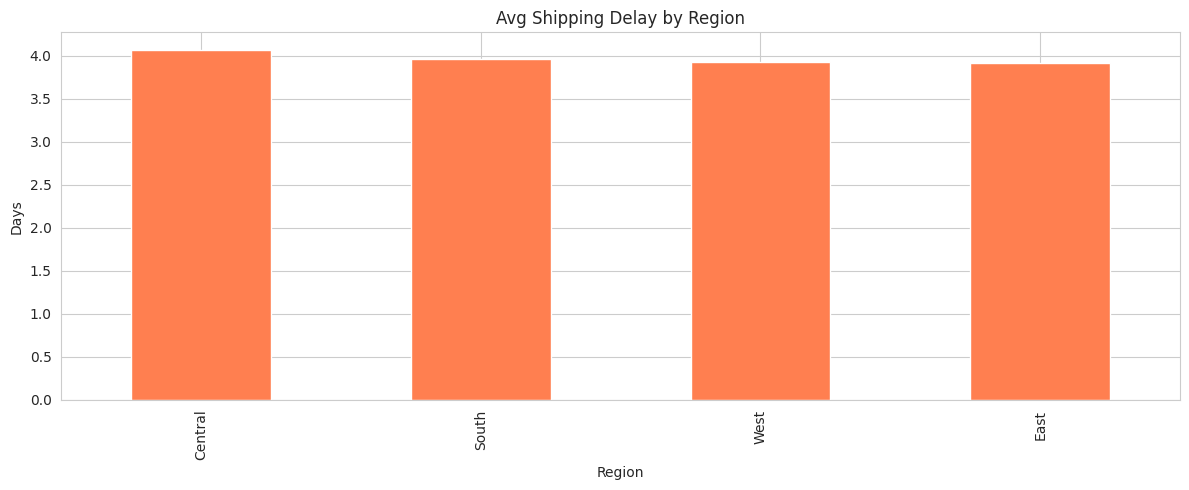

In [9]:
df['Ship_Delay_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

print("Overall average shipping delay:", df['Ship_Delay_Days'].mean().round(2), "days")

region_ship_delay = df.groupby('Region')['Ship_Delay_Days'].mean().sort_values(ascending=False)
print("\nBy region:\n", region_ship_delay)

region_ship_delay.plot(kind='bar', color='coral', title='Avg Shipping Delay by Region')
plt.ylabel('Days')
plt.tight_layout()
plt.show()

# Q4: Seasonality — months that spike every year

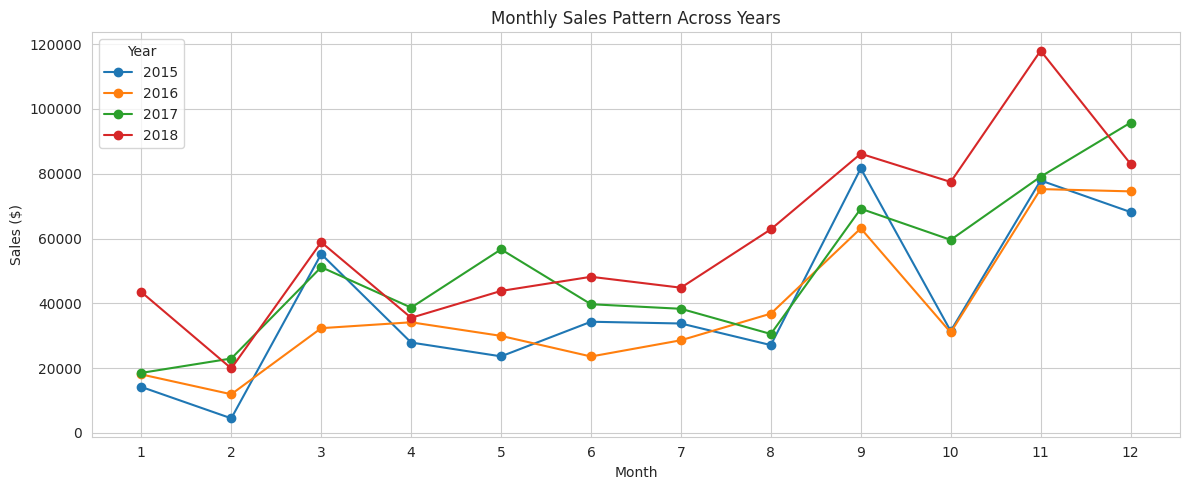

Average sales by calendar month (highest first):
 Month
3     290.549393
1     257.627403
10    246.596162
11    241.657496
12    232.619515
8     227.007110
9     221.642106
5     212.533412
6     211.052856
7     208.802997
4     207.432269
2     199.902745
Name: Sales, dtype: float64


In [10]:
monthly_pattern = df.groupby(['Year', 'Month'])['Sales'].sum().unstack(level=0)
monthly_pattern.plot(marker='o', title='Monthly Sales Pattern Across Years')
plt.xlabel('Month')
plt.ylabel('Sales ($)')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

# Average sales per calendar month across all years
avg_monthly = df.groupby('Month')['Sales'].mean().sort_values(ascending=False)
print("Average sales by calendar month (highest first):\n", avg_monthly)

#  Import & install

In [11]:
!pip install statsmodels -q
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# Set monthly sales as time-indexed series

In [12]:
ts_monthly = monthly_sales.set_index('Month')['Total_Sales']
ts_monthly = ts_monthly.asfreq('ME')  # ensure regular monthly frequency
ts_monthly.head()

,Total_Sales
Month,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


#  Plot overall trend

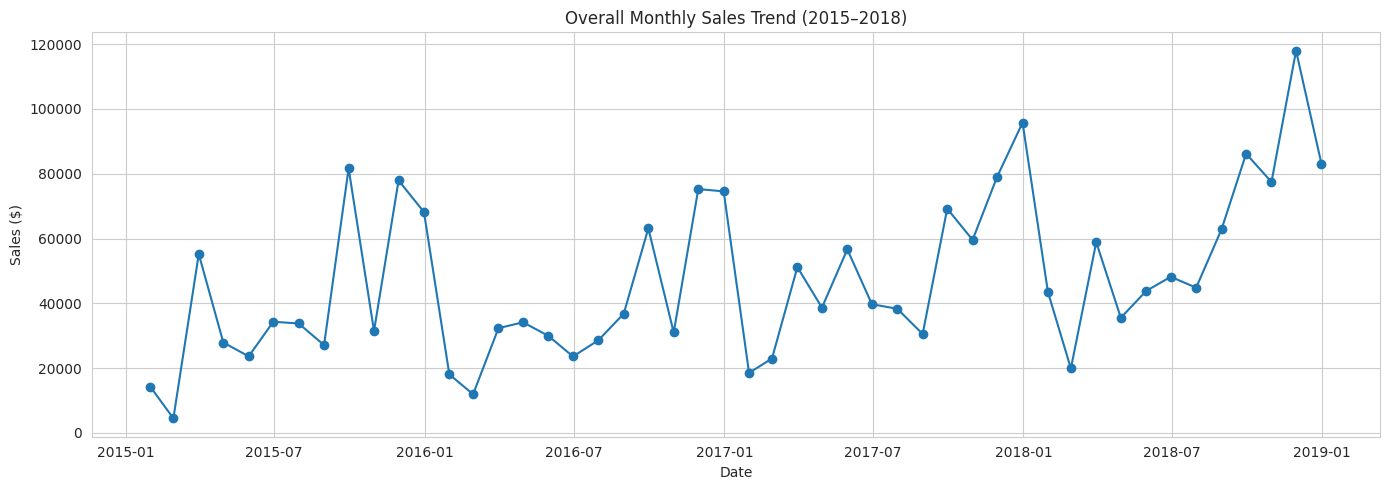

In [13]:
plt.figure(figsize=(14, 5))
plt.plot(ts_monthly, marker='o')
plt.title('Overall Monthly Sales Trend (2015–2018)')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.show()

#  Decomposition

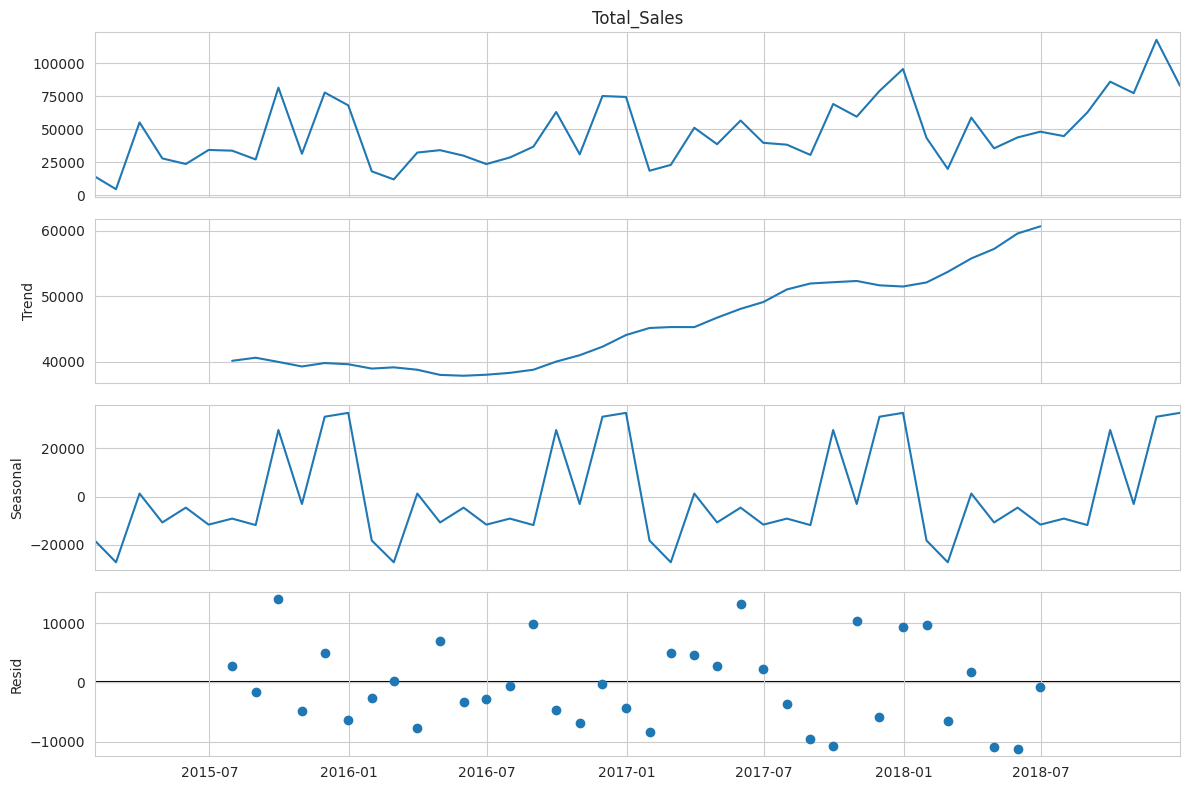

In [14]:
decomposition = seasonal_decompose(ts_monthly, model='additive', period=12)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

# Extract components for analysis



In [15]:
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

print("Residual std dev (noise level):", residual.std())
print("\nMonths with highest residual (most 'surprising'):")
print(residual.abs().sort_values(ascending=False).head(5))

Residual std dev (noise level): 7040.944808923006

Months with highest residual (most 'surprising'):
Month
2015-09-30    13970.933082
2017-05-31    13193.079793
2018-05-31    11157.549320
2018-04-30    10916.959724
2017-09-30    10642.715643
Name: resid, dtype: float64


# ADF Test (stationarity check)

In [16]:
def run_adf_test(series, title=''):
    result = adfuller(series.dropna())
    print(f'--- ADF Test: {title} ---')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Critical Values:')
    for key, val in result[4].items():
        print(f'   {key}: {val:.4f}')
    if result[1] <= 0.05:
        print("=> Series is STATIONARY (reject H0)\n")
    else:
        print("=> Series is NON-STATIONARY (fail to reject H0)\n")
    return result[1]

pval = run_adf_test(ts_monthly, 'Original Monthly Sales')

--- ADF Test: Original Monthly Sales ---
ADF Statistic: -4.4161
p-value: 0.0003
Critical Values:
   1%: -3.5778
   5%: -2.9253
   10%: -2.6008
=> Series is STATIONARY (reject H0)



# Differencing if non-stationary

In [17]:
if pval > 0.05:
    ts_diff = ts_monthly.diff().dropna()

    plt.figure(figsize=(14, 4))
    plt.plot(ts_diff)
    plt.title('First-Order Differenced Series')
    plt.tight_layout()
    plt.savefig('charts/differenced_series.png')
    plt.show()

    run_adf_test(ts_diff, 'Differenced Monthly Sales')
else:
    print("Original series already stationary — no differencing needed.")
    ts_diff = ts_monthly.copy()

Original series already stationary — no differencing needed.


# Install

In [18]:
!pip install pmdarima prophet xgboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 17.5 MB/s eta 0:00:00


# Train/Test split (time-based)

In [19]:
train = ts_monthly[:-3]
test = ts_monthly[-3:]

print("Train range:", train.index.min(), "to", train.index.max())
print("Test range:", test.index.min(), "to", test.index.max())
print("Train size:", len(train), "| Test size:", len(test))

Train range: 2015-01-31 00:00:00 to 2018-09-30 00:00:00
Test range: 2018-10-31 00:00:00 to 2018-12-31 00:00:00
Train size: 45 | Test size: 3


# Evaluation metric function (reused for all 3 models)

In [20]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate_forecast(actual, predicted, model_name=''):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f"{model_name} -> MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%")
    return {'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

results = []  # will collect all model results for the comparison table

# Model 1 — SARIMA
  Auto-select SARIMA parameters

In [21]:
import pmdarima as pm

auto_model = pm.auto_arima(
    train,
    seasonal=True,
    m=12,
    d=None, D=None,        # auto-detect differencing needed
    trace=True,
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=1009.639, Time=0.84 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=1025.765, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=1007.450, Time=0.09 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=1007.755, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=1023.942, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=1020.706, Time=0.03 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=1009.338, Time=0.13 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=1009.427, Time=0.20 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=1011.652, Time=0.23 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=1011.126, Time=1.04 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=1012.838, Time=0.31 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=1004.192, Time=0.73 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=1017.580, Time=0.20 sec
 ARIMA(2,1,0)(2,0,0)[12] intercept   : AIC=1005.949, Time=1.27 sec
 ARIMA(2,1,0)(1,0,1

#  Fit SARIMA with statsmodels using selected order

In [22]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

order = auto_model.order
seasonal_order = auto_model.seasonal_order
print("Using order:", order, "seasonal_order:", seasonal_order)

sarima_model = SARIMAX(train, order=order, seasonal_order=seasonal_order,
                        enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima_model.fit(disp=False)

Using order: (2, 1, 0) seasonal_order: (1, 0, 0, 12)


# Forecast 3 months + confidence intervals

In [23]:
sarima_forecast = sarima_fit.get_forecast(steps=3)
sarima_pred = sarima_forecast.predicted_mean
sarima_ci = sarima_forecast.conf_int()

print(sarima_pred)
print(sarima_ci)

2018-10-31     73694.394183
2018-11-30     95396.644905
2018-12-31    107210.643143
Freq: ME, Name: predicted_mean, dtype: float64
            lower Total_Sales  upper Total_Sales
2018-10-31       50130.402735       97258.385632
2018-11-30       69985.052981      120808.236829
2018-12-31       80340.325120      134080.961165


#  Plot actual vs forecast

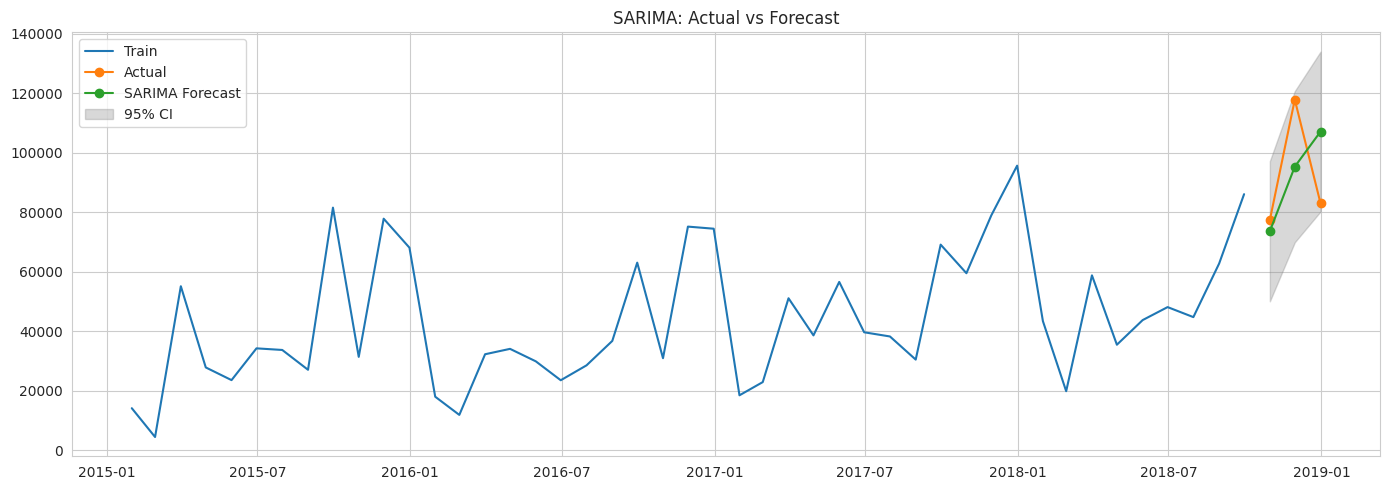

SARIMA -> MAE: 16825.17 | RMSE: 19208.46 | MAPE: 17.69%


In [24]:
plt.figure(figsize=(14, 5))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual', marker='o')
plt.plot(sarima_pred.index, sarima_pred, label='SARIMA Forecast', marker='o')
plt.fill_between(sarima_ci.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], color='gray', alpha=0.3, label='95% CI')
plt.legend()
plt.title('SARIMA: Actual vs Forecast')
plt.tight_layout()
plt.show()

results.append(evaluate_forecast(test.values, sarima_pred.values, 'SARIMA'))

# Model 2- Prophet
Prepare data in Prophet format

In [25]:
from prophet import Prophet

prophet_df = ts_monthly.reset_index()
prophet_df.columns = ['ds', 'y']

prophet_train = prophet_df.iloc[:-3]
prophet_test = prophet_df.iloc[-3:]

prophet_train.tail()

,ds,y
40,2018-05-31,43825.9822
41,2018-06-30,48190.7277
42,2018-07-31,44825.1040
43,2018-08-31,62837.8480
44,2018-09-30,86152.8880


#  Fit Prophet

In [26]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,   # monthly data, weekly seasonality not meaningful
    daily_seasonality=False
)
prophet_model.fit(prophet_train)

# Forecast 3 months

In [27]:
future = prophet_model.make_future_dataframe(periods=3, freq='ME')
prophet_forecast = prophet_model.predict(future)

prophet_forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(3)

,ds,yhat,yhat_lower,yhat_upper
45,2018-10-31,51318.943812,42830.156982,59373.075446
46,2018-11-30,90325.654736,81949.821880,98505.267176
47,2018-12-31,90041.084430,81952.916457,98044.052126


#  Plot Forecast

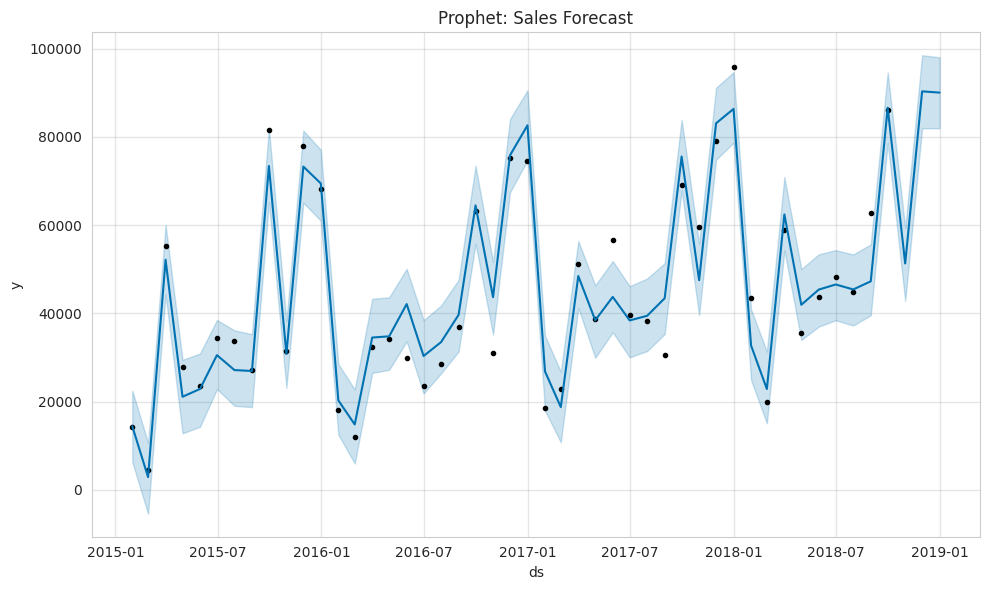

In [28]:
fig1 = prophet_model.plot(prophet_forecast)
plt.title('Prophet: Sales Forecast')
plt.tight_layout()
plt.show()

# Trend & seasonality components

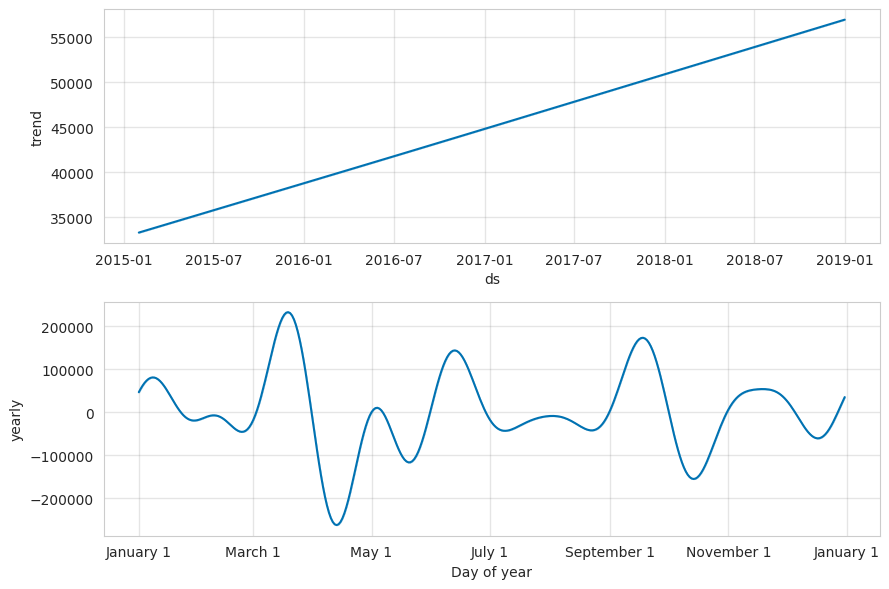

In [29]:
fig2 = prophet_model.plot_components(prophet_forecast)
plt.tight_layout()
plt.show()

#  Evaluate on test set

In [30]:
prophet_pred = prophet_forecast.iloc[-3:]['yhat'].values
actual_vals = prophet_test['y'].values

results.append(evaluate_forecast(actual_vals, prophet_pred, 'Prophet'))

Prophet -> MAE: 20250.79 | RMSE: 22318.41 | MAPE: 21.86%


# Actual vs Predicted comparison plot (test period only, cleaner view)

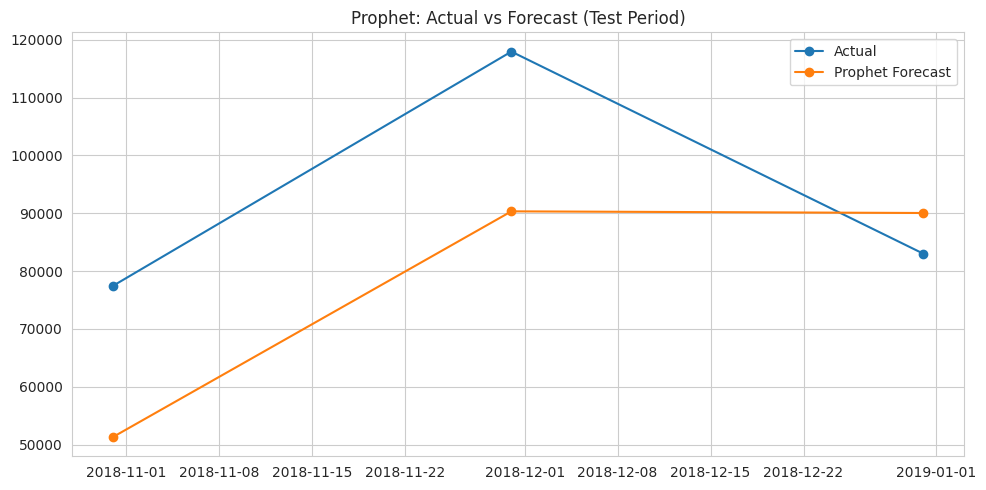

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(prophet_test['ds'], actual_vals, label='Actual', marker='o')
plt.plot(prophet_test['ds'], prophet_pred, label='Prophet Forecast', marker='o')
plt.legend()
plt.title('Prophet: Actual vs Forecast (Test Period)')
plt.tight_layout()

plt.show()

#  Feature engineering: lag features

In [32]:
xgb_df = ts_monthly.reset_index()
xgb_df.columns = ['Month', 'Sales']

xgb_df['Lag1'] = xgb_df['Sales'].shift(1)
xgb_df['Lag2'] = xgb_df['Sales'].shift(2)
xgb_df['Lag3'] = xgb_df['Sales'].shift(3)
xgb_df['Rolling_Mean_3'] = xgb_df['Sales'].shift(1).rolling(window=3).mean()

xgb_df['Month_num'] = xgb_df['Month'].dt.month
xgb_df['Quarter'] = xgb_df['Month'].dt.quarter
xgb_df['Season'] = xgb_df['Month'].dt.month.apply(get_season)

# One-hot encode Season
xgb_df = pd.get_dummies(xgb_df, columns=['Season'], drop_first=True)

xgb_df = xgb_df.dropna().reset_index(drop=True)
xgb_df.head()

,Month,Sales,Lag1,Lag2,Lag3,Rolling_Mean_3,Month_num,Quarter,Season_Spring,Season_Summer,Season_Winter
0,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,24643.798667,4,2,True,False,False
1,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,29210.848000,5,2,True,False,False
2,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,35585.651667,6,2,False,True,False
3,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,28624.697867,7,3,False,True,False
4,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,30582.927200,8,3,False,True,False


# Train/test split

In [33]:
feature_cols = [c for c in xgb_df.columns if c not in ['Month', 'Sales']]

X = xgb_df[feature_cols]
y = xgb_df['Sales']

X_train, X_test = X.iloc[:-3], X.iloc[-3:]
y_train, y_test = y.iloc[:-3], y.iloc[-3:]

print(X_train.shape, X_test.shape)
X_train.head()

(42, 9) (3, 9)


,Lag1,Lag2,Lag3,Rolling_Mean_3,Month_num,Quarter,Season_Spring,Season_Summer,Season_Winter
0,55205.7970,4519.8920,14205.707,24643.798667,4,2,True,False,False
1,27906.8550,55205.7970,4519.892,29210.848000,5,2,True,False,False
2,23644.3030,27906.8550,55205.797,35585.651667,6,2,False,True,False
3,34322.9356,23644.3030,27906.855,28624.697867,7,3,False,True,False
4,33781.5430,34322.9356,23644.303,30582.927200,8,3,False,True,False


#  Train XGBoost

In [34]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

#  Predict & evaluate

In [35]:
xgb_pred = xgb_model.predict(X_test)

results.append(evaluate_forecast(y_test.values, xgb_pred, 'XGBoost'))

XGBoost -> MAE: 18909.94 | RMSE: 21009.26 | MAPE: 19.39%


# — Plot actual vs predicted

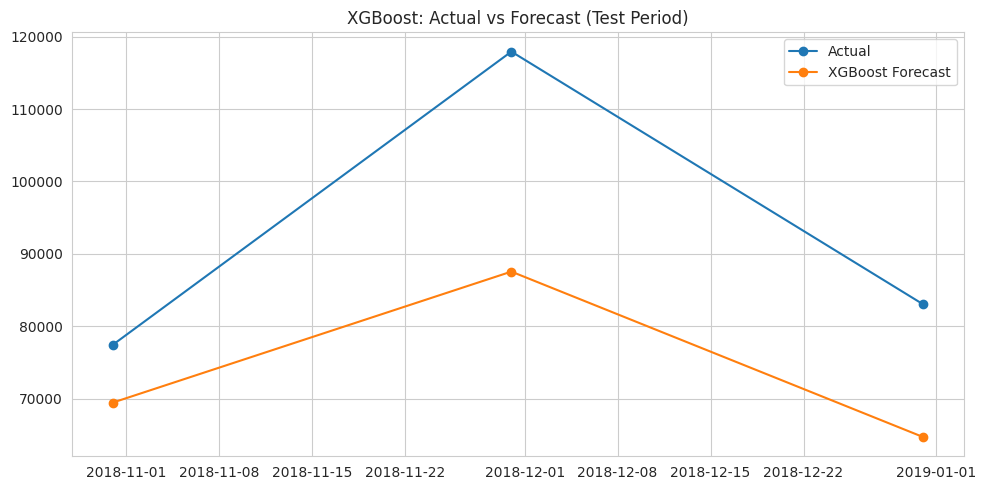

In [36]:
test_months = xgb_df['Month'].iloc[-3:]

plt.figure(figsize=(10, 5))
plt.plot(test_months, y_test.values, label='Actual', marker='o')
plt.plot(test_months, xgb_pred, label='XGBoost Forecast', marker='o')
plt.legend()
plt.title('XGBoost: Actual vs Forecast (Test Period)')
plt.tight_layout()

plt.show()

#  Feature importance

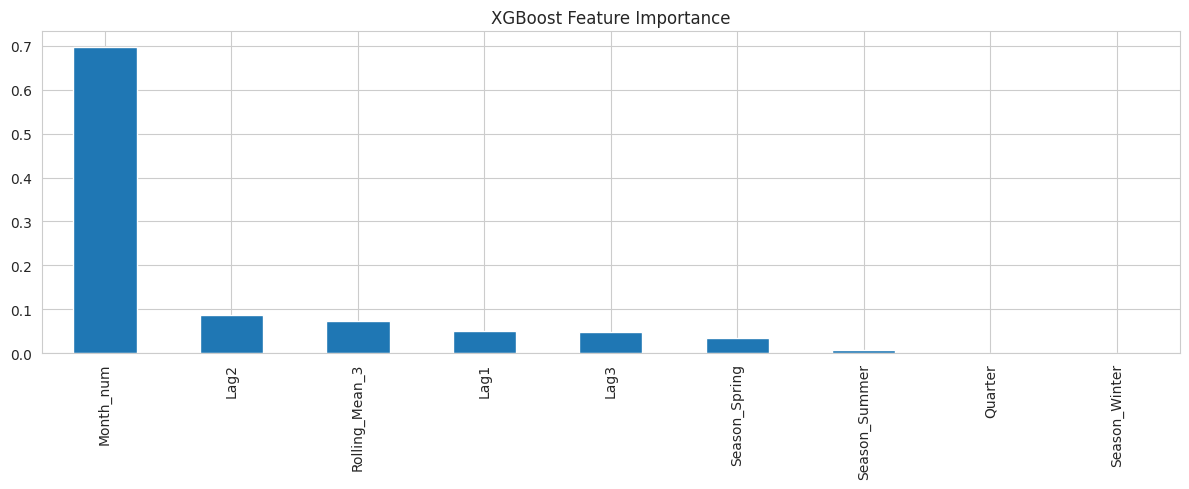

Month_num         0.697771
Lag2              0.087603
Rolling_Mean_3    0.073988
Lag1              0.050976
Lag3              0.047299
Season_Spring     0.035124
Season_Summer     0.007239
Quarter           0.000000
Season_Winter     0.000000
dtype: float32


In [37]:
importance = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
importance.plot(kind='bar', title='XGBoost Feature Importance')
plt.tight_layout()
plt.show()
print(importance)

# Build comparison table with forecasts

In [38]:
comparison_df = pd.DataFrame(results)

# Add the 3-month forecast values for each model
comparison_df['Forecast_Month1'] = [sarima_pred.values[0], prophet_pred[0], xgb_pred[0]]
comparison_df['Forecast_Month2'] = [sarima_pred.values[1], prophet_pred[1], xgb_pred[1]]
comparison_df['Forecast_Month3'] = [sarima_pred.values[2], prophet_pred[2], xgb_pred[2]]

comparison_df = comparison_df[['Model', 'MAE', 'RMSE', 'MAPE',
                                 'Forecast_Month1', 'Forecast_Month2', 'Forecast_Month3']]
comparison_df = comparison_df.round(2)
comparison_df

,Model,MAE,RMSE,MAPE,Forecast_Month1,Forecast_Month2,Forecast_Month3
0,SARIMA,16825.17,19208.46,17.69,73694.39,95396.64,107210.64
1,Prophet,20250.79,22318.41,21.86,51318.94,90325.65,90041.08
2,XGBoost,18909.94,21009.26,19.39,69453.98,87542.14,64690.73


# Save table + identify best model

In [39]:
import os

# Create the directory if it doesn't exist
os.makedirs('charts', exist_ok=True)

comparison_df.to_csv('charts/model_comparison.csv', index=False)

best_model_name = comparison_df.loc[comparison_df['MAPE'].idxmin(), 'Model']
print(f"Recommended model for production: {best_model_name}")
print(f"(Lowest MAPE = {comparison_df['MAPE'].min():.2f}%")

Recommended model for production: SARIMA
(Lowest MAPE = 17.69%


# Visual comparison of all 3 models on test period

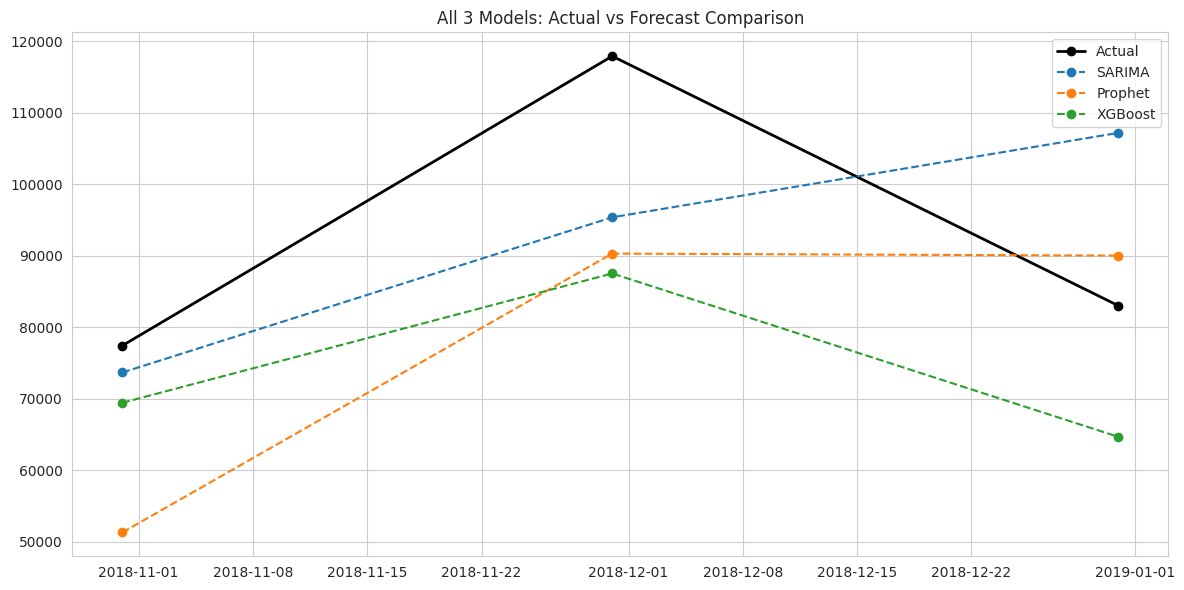

In [40]:
plt.figure(figsize=(12, 6))
plt.plot(test.index, test.values, label='Actual', marker='o', linewidth=2, color='black')
plt.plot(sarima_pred.index, sarima_pred.values, label='SARIMA', marker='o', linestyle='--')
plt.plot(test.index, prophet_pred, label='Prophet', marker='o', linestyle='--')
plt.plot(test.index, xgb_pred, label='XGBoost', marker='o', linestyle='--')
plt.legend()
plt.title('All 3 Models: Actual vs Forecast Comparison')
plt.tight_layout()
plt.show()

# Helper function to build monthly series for any segment

In [41]:
def get_segment_monthly_series(df, column, value):
    segment_df = df[df[column] == value]
    monthly = segment_df.groupby(pd.Grouper(key='Order Date', freq='ME'))['Sales'].sum()
    monthly = monthly.asfreq('ME').fillna(0)  # fill missing months with 0 sales
    return monthly

# quick check
get_segment_monthly_series(df, 'Category', 'Furniture').tail()

,Sales
Order Date,
2018-08-31,15419.1220
2018-09-30,28516.7060
2018-10-31,21884.0682
2018-11-30,37056.7150
2018-12-31,31407.4668


# Helper function to fit SARIMA and forecast for a segment

In [42]:
def forecast_segment_sarima(series, steps=3):
    train_seg = series[:-3]

    model = SARIMAX(train_seg, order=order, seasonal_order=seasonal_order,
                     enforce_stationarity=False, enforce_invertibility=False)
    fit = model.fit(disp=False)

    forecast = fit.get_forecast(steps=steps)
    pred = forecast.predicted_mean
    return pred

# order and seasonal_order reused from Task 3's auto_arima result: (2,1,0)(1,0,0,12)

# Run forecast for all 5 segments

In [43]:
segments = {
    'Furniture': ('Category', 'Furniture'),
    'Technology': ('Category', 'Technology'),
    'Office Supplies': ('Category', 'Office Supplies'),
    'West': ('Region', 'West'),
    'East': ('Region', 'East')
}

segment_series = {}
segment_forecasts = {}

for name, (col, val) in segments.items():
    series = get_segment_monthly_series(df, col, val)
    segment_series[name] = series
    try:
        segment_forecasts[name] = forecast_segment_sarima(series)
        print(f"{name}: forecast done")
    except Exception as e:
        print(f"{name}: FAILED - {e}")

Furniture: forecast done
Technology: forecast done
Office Supplies: forecast done
West: forecast done
East: forecast done


#  Plot all 5 forecasts together

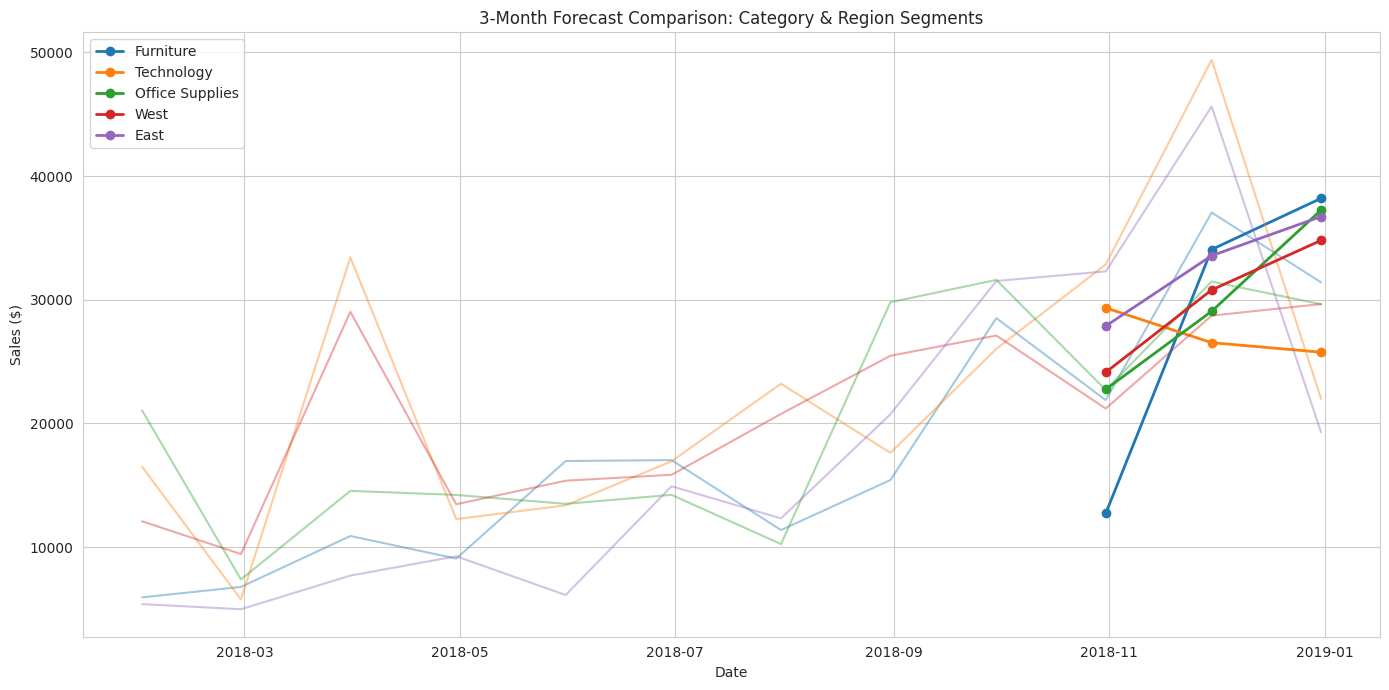

In [44]:
plt.figure(figsize=(14, 7))

colors = plt.cm.tab10.colors

for i, (name, series) in enumerate(segment_series.items()):
    # plot last 12 months of actual history for context
    recent_actual = series[-12:]
    plt.plot(recent_actual.index, recent_actual.values, color=colors[i], alpha=0.4)

    if name in segment_forecasts:
        pred = segment_forecasts[name]
        plt.plot(pred.index, pred.values, color=colors[i], marker='o', label=name, linewidth=2)

plt.legend()
plt.title('3-Month Forecast Comparison: Category & Region Segments')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.tight_layout()
plt.savefig('charts/segment_forecast_comparison.png')
plt.show()

# Growth rate summary (which segment growing fastest)

In [45]:
growth_summary = []
for name, series in segment_series.items():
    if name in segment_forecasts:
        last_actual = series.iloc[-1]
        forecast_avg = segment_forecasts[name].mean()
        growth_pct = ((forecast_avg - last_actual) / last_actual) * 100
        growth_summary.append({'Segment': name, 'Last_Actual': last_actual,
                                'Forecast_Avg': forecast_avg, 'Growth_%': growth_pct})

growth_df = pd.DataFrame(growth_summary).sort_values('Growth_%', ascending=False)
growth_df.round(2)

,Segment,Last_Actual,Forecast_Avg,Growth_%
4,East,19285.49,32725.29,69.69
1,Technology,21984.91,27211.93,23.78
3,West,29652.10,29909.42,0.87
2,Office Supplies,29638.01,29693.12,0.19
0,Furniture,31407.47,28330.89,-9.80


# Prepare weekly sales data for anomaly detection

In [46]:
from sklearn.ensemble import IsolationForest

anomaly_df = weekly_sales.copy()
anomaly_df.columns = ['Week', 'Sales']
anomaly_df = anomaly_df.set_index('Week')
anomaly_df.head()

,Sales
Week,
2015-01-04,304.508
2015-01-11,4619.108
2015-01-18,4130.533
2015-01-25,3092.544
2015-02-01,2527.914


#  Method 1: Isolation Forest

In [47]:
iso_forest = IsolationForest(contamination=0.05, random_state=42)
anomaly_df['IF_Anomaly'] = iso_forest.fit_predict(anomaly_df[['Sales']])

# -1 = anomaly, 1 = normal → convert to boolean for readability
anomaly_df['IF_Anomaly'] = anomaly_df['IF_Anomaly'] == -1

print("Isolation Forest flagged anomalies:", anomaly_df['IF_Anomaly'].sum())
anomaly_df[anomaly_df['IF_Anomaly']]

Isolation Forest flagged anomalies: 11


,Sales,IF_Anomaly
Week,,
2015-01-04,304.508,True
2015-02-08,968.534,True
2015-02-22,224.912,True
2015-03-22,37703.665,True
2015-07-19,1387.686,True
2015-09-13,29959.137,True
2016-01-24,358.522,True
2017-12-17,25449.800,True
2018-11-04,29017.467,True


# Plot Isolation Forest anomalies

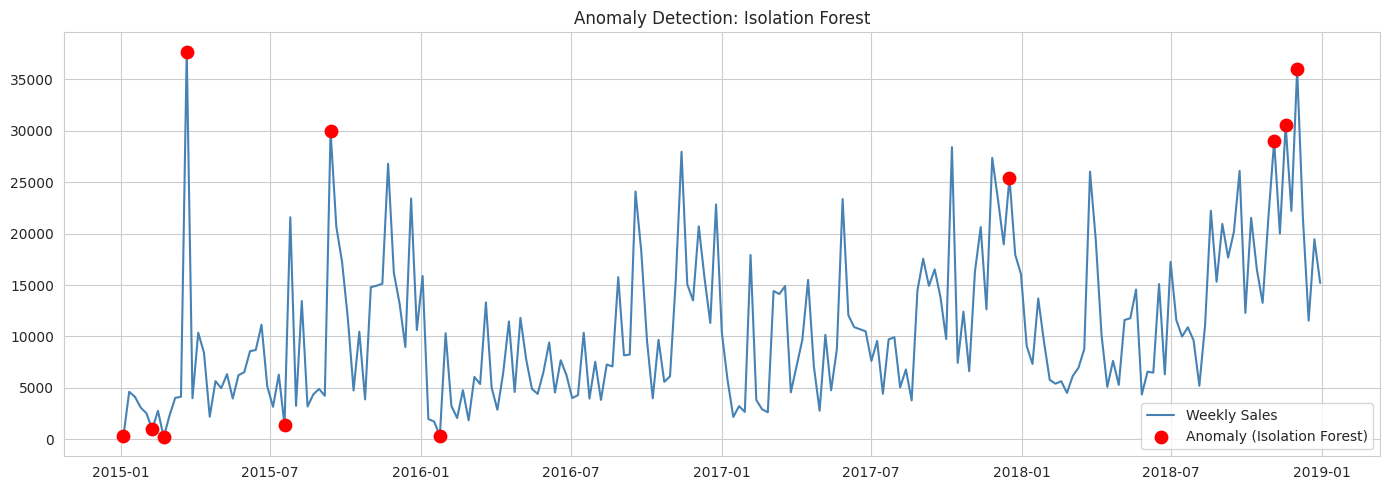

In [48]:
plt.figure(figsize=(14, 5))
plt.plot(anomaly_df.index, anomaly_df['Sales'], label='Weekly Sales', color='steelblue')
plt.scatter(anomaly_df[anomaly_df['IF_Anomaly']].index,
            anomaly_df[anomaly_df['IF_Anomaly']]['Sales'],
            color='red', s=80, zorder=5, label='Anomaly (Isolation Forest)')
plt.legend()
plt.title('Anomaly Detection: Isolation Forest')
plt.tight_layout()
plt.savefig('charts/anomaly_isolation_forest.png')
plt.show()

# Method 2: Z-score based on rolling mean

In [49]:
window = 8  # 8-week rolling window
anomaly_df['Rolling_Mean'] = anomaly_df['Sales'].rolling(window=window, center=True).mean()
anomaly_df['Rolling_Std'] = anomaly_df['Sales'].rolling(window=window, center=True).std()
anomaly_df['Z_Score'] = (anomaly_df['Sales'] - anomaly_df['Rolling_Mean']) / anomaly_df['Rolling_Std']

anomaly_df['Zscore_Anomaly'] = anomaly_df['Z_Score'].abs() > 2

print("Z-Score flagged anomalies:", anomaly_df['Zscore_Anomaly'].sum())
anomaly_df[anomaly_df['Zscore_Anomaly']]

Z-Score flagged anomalies: 6


,Sales,IF_Anomaly,Rolling_Mean,Rolling_Std,Z_Score,Zscore_Anomaly
Week,,,,,,
2015-03-22,37703.665,True,8896.190250,12079.340151,2.384855,True
2015-07-26,21590.080,False,7183.553750,6897.327905,2.088711,True
2016-03-20,13310.136,False,5712.780425,3439.251848,2.209014,True
2017-02-05,17926.368,False,5141.228750,5284.147247,2.419527,True
2017-05-28,23367.662,False,10442.132500,6138.903372,2.105511,True
2017-10-08,28412.098,False,13742.872737,6891.136042,2.128709,True


# Plot Z-score anomalies

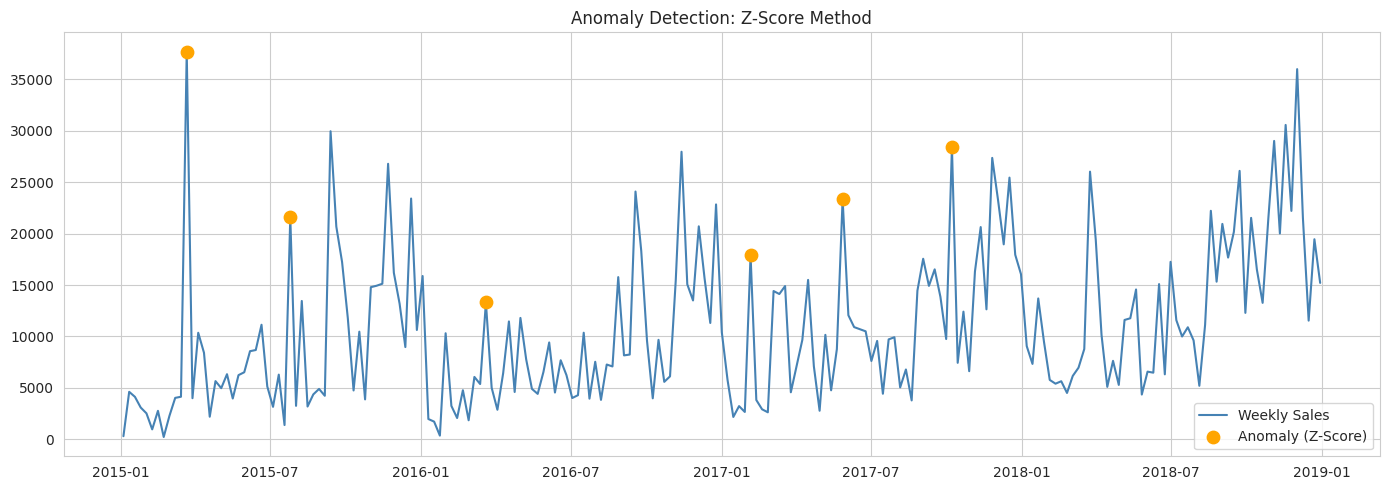

In [50]:
plt.figure(figsize=(14, 5))
plt.plot(anomaly_df.index, anomaly_df['Sales'], label='Weekly Sales', color='steelblue')
plt.scatter(anomaly_df[anomaly_df['Zscore_Anomaly']].index,
            anomaly_df[anomaly_df['Zscore_Anomaly']]['Sales'],
            color='orange', s=80, zorder=5, label='Anomaly (Z-Score)')
plt.legend()
plt.title('Anomaly Detection: Z-Score Method')
plt.tight_layout()
plt.show()

# Compare both methods

In [51]:
both_agree = anomaly_df[anomaly_df['IF_Anomaly'] & anomaly_df['Zscore_Anomaly']]
only_if = anomaly_df[anomaly_df['IF_Anomaly'] & ~anomaly_df['Zscore_Anomaly']]
only_zscore = anomaly_df[~anomaly_df['IF_Anomaly'] & anomaly_df['Zscore_Anomaly']]

print(f"Both methods agree on: {len(both_agree)} weeks")
print(f"Only Isolation Forest flagged: {len(only_if)} weeks")
print(f"Only Z-Score flagged: {len(only_zscore)} weeks")

print("\nAgreed anomaly dates:")
print(both_agree.index.tolist())

Both methods agree on: 1 weeks
Only Isolation Forest flagged: 10 weeks
Only Z-Score flagged: 5 weeks

Agreed anomaly dates:
[Timestamp('2015-03-22 00:00:00')]


# Add real-world explanation for top anomalies


In [52]:
top_anomalies = anomaly_df[anomaly_df['IF_Anomaly'] | anomaly_df['Zscore_Anomaly']].sort_values('Sales', ascending=False).head(5)
top_anomalies[['Sales', 'IF_Anomaly', 'Zscore_Anomaly']]

,Sales,IF_Anomaly,Zscore_Anomaly
Week,,,
2015-03-22,37703.665,True,True
2018-12-02,35998.900,True,False
2018-11-18,30572.447,True,False
2015-09-13,29959.137,True,False
2018-11-04,29017.467,True,False


# Aggregate features at sub-category level

In [53]:
subcat_features = df.groupby('Sub-Category').agg(
    Total_Sales=('Sales', 'sum'),
    Avg_Order_Value=('Sales', 'mean')
).reset_index()

# Year-over-year growth rate
yearly_subcat = df.groupby(['Sub-Category', 'Year'])['Sales'].sum().unstack(level=1)
yoy_growth_rate = ((yearly_subcat[2018] - yearly_subcat[2015]) / yearly_subcat[2015]) * 100
subcat_features = subcat_features.merge(yoy_growth_rate.rename('Growth_Rate_Pct'), on='Sub-Category')

# Volatility = std dev of monthly sales
monthly_subcat = df.groupby(['Sub-Category', pd.Grouper(key='Order Date', freq='ME')])['Sales'].sum().reset_index()
volatility = monthly_subcat.groupby('Sub-Category')['Sales'].std()
subcat_features = subcat_features.merge(volatility.rename('Volatility'), on='Sub-Category')

subcat_features

,Sub-Category,Total_Sales,Avg_Order_Value,Growth_Rate_Pct,Volatility
0,Accessories,164186.7000,217.178175,145.055961,2579.994809
1,Appliances,104618.4030,227.926804,165.242912,1821.621539
2,Art,26705.4100,34.019631,49.649531,330.488343
3,Binders,200028.7850,134.067550,65.778638,3848.223648
4,Bookcases,113813.1987,503.598224,49.846598,2220.405080
5,Chairs,322822.7310,531.833165,20.954677,4407.232960
6,Copiers,146248.0940,2215.880212,479.729510,5500.774391
7,Envelopes,16128.0460,65.032444,-12.121345,228.218688
8,Fasteners,3001.9600,14.027850,30.468364,48.742229
9,Furnishings,89212.0180,95.823865,106.824969,1360.017867


#  Scale features

In [54]:
from sklearn.preprocessing import StandardScaler

cluster_features = ['Total_Sales', 'Growth_Rate_Pct', 'Volatility', 'Avg_Order_Value']
X_cluster = subcat_features[cluster_features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow method to find optimal K

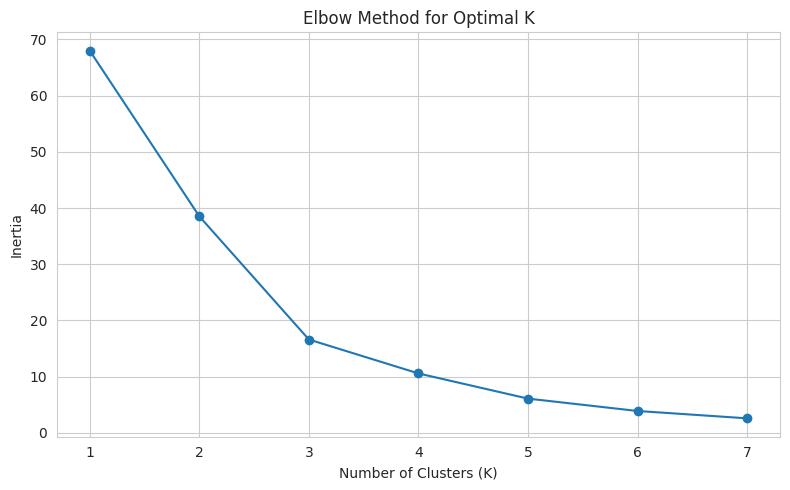

In [55]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(1, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.tight_layout()
plt.savefig('charts/elbow_method.png')
plt.show()

#  Fit K-Means with chosen K

In [56]:
optimal_k = 4  # <-- update this based on elbow plot

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
subcat_features['Cluster'] = kmeans.fit_predict(X_scaled)

subcat_features.sort_values('Cluster')

,Sub-Category,Total_Sales,Avg_Order_Value,Growth_Rate_Pct,Volatility,Cluster
0,Accessories,164186.7000,217.178175,145.055961,2579.994809,0
3,Binders,200028.7850,134.067550,65.778638,3848.223648,0
5,Chairs,322822.7310,531.833165,20.954677,4407.232960,0
14,Storage,219343.3920,263.633885,38.366108,2822.084310,0
13,Phones,327782.4480,374.180877,35.557607,4052.718221,0
16,Tables,202810.6280,645.893720,33.078016,3224.082504,0
6,Copiers,146248.0940,2215.880212,479.729510,5500.774391,1
2,Art,26705.4100,34.019631,49.649531,330.488343,2
7,Envelopes,16128.0460,65.032444,-12.121345,228.218688,2
4,Bookcases,113813.1987,503.598224,49.846598,2220.405080,2


#  Label clusters meaningfully

In [57]:
cluster_summary = subcat_features.groupby('Cluster')[cluster_features].mean().round(2)
cluster_summary['Count'] = subcat_features['Cluster'].value_counts().sort_index()
cluster_summary

,Total_Sales,Growth_Rate_Pct,Volatility,Avg_Order_Value,Count
Cluster,,,,,
0,239495.78,56.47,3489.06,361.13,6
1,146248.09,479.73,5500.77,2215.88,1
2,54341.71,58.80,1031.43,142.75,9
3,189238.63,-29.79,5603.55,1645.55,1


# Assign meaningful labels

In [58]:
cluster_labels = {
    0: 'High Volume, Stable Demand',
    1: 'Explosive Growth',
    2: 'Low Volume, Stable Demand',
    3: 'Declining Demand, High Volatility'
}

subcat_features['Cluster_Label'] = subcat_features['Cluster'].map(cluster_labels)
subcat_features[['Sub-Category', 'Cluster', 'Cluster_Label']].sort_values('Cluster')

,Sub-Category,Cluster,Cluster_Label
0,Accessories,0,"High Volume, Stable Demand"
3,Binders,0,"High Volume, Stable Demand"
5,Chairs,0,"High Volume, Stable Demand"
14,Storage,0,"High Volume, Stable Demand"
13,Phones,0,"High Volume, Stable Demand"
16,Tables,0,"High Volume, Stable Demand"
6,Copiers,1,Explosive Growth
2,Art,2,"Low Volume, Stable Demand"
7,Envelopes,2,"Low Volume, Stable Demand"
4,Bookcases,2,"Low Volume, Stable Demand"


# PCA for 2D visualization

In [59]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

subcat_features['PCA1'] = pca_result[:, 0]
subcat_features['PCA2'] = pca_result[:, 1]

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance explained:", pca.explained_variance_ratio_.sum().round(3))

Explained variance ratio: [0.61842085 0.28139218]
Total variance explained: 0.9


#  Plot clusters

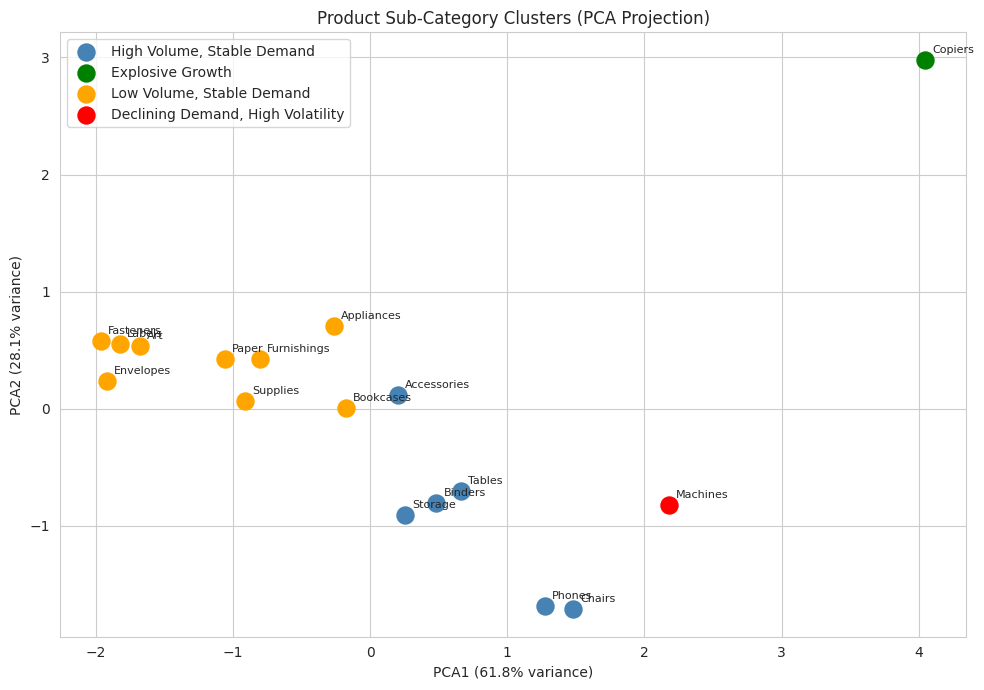

In [60]:
plt.figure(figsize=(10, 7))
colors_map = {0: 'steelblue', 1: 'green', 2: 'orange', 3: 'red'}

for cluster_id in sorted(subcat_features['Cluster'].unique()):
    subset = subcat_features[subcat_features['Cluster'] == cluster_id]
    plt.scatter(subset['PCA1'], subset['PCA2'],
                color=colors_map[cluster_id], s=150,
                label=cluster_labels[cluster_id])
    for _, row in subset.iterrows():
        plt.annotate(row['Sub-Category'], (row['PCA1'], row['PCA2']),
                     fontsize=8, xytext=(5, 5), textcoords='offset points')

plt.xlabel(f'PCA1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PCA2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('Product Sub-Category Clusters (PCA Projection)')
plt.legend()
plt.tight_layout()
plt.show()

#  Stocking strategy recommendations

In [61]:
stocking_strategy = {
    'High Volume, Stable Demand': 'Maintain steady safety stock; use standard reorder-point models. Low risk of overstock/understock.',
    'Explosive Growth': 'Increase order frequency and safety stock aggressively; monitor weekly — risk of stockouts if growth continues.',
    'Low Volume, Stable Demand': 'Minimal inventory investment; order in small batches, low priority for warehouse space.',
    'Declining Demand, High Volatility': 'Reduce stock levels cautiously; investigate cause of decline before further cuts; avoid bulk purchasing.'
}

for label, strategy in stocking_strategy.items():
    print(f"{label}:\n  -> {strategy}\n")

High Volume, Stable Demand:
  -> Maintain steady safety stock; use standard reorder-point models. Low risk of overstock/understock.

Explosive Growth:
  -> Increase order frequency and safety stock aggressively; monitor weekly — risk of stockouts if growth continues.

Low Volume, Stable Demand:
  -> Minimal inventory investment; order in small batches, low priority for warehouse space.

Declining Demand, High Volatility:
  -> Reduce stock levels cautiously; investigate cause of decline before further cuts; avoid bulk purchasing.



# Step A — Save artifacts
Save all data/models needed for dashboard

In [62]:
import pickle
import os

os.makedirs('dashboard_data', exist_ok=True)

# 1. Raw cleaned data (for overview page filters)
df.to_csv('dashboard_data/cleaned_sales.csv', index=False)

# 2. Monthly sales series (for forecast explorer)
ts_monthly.to_csv('dashboard_data/monthly_sales.csv')

# 3. Model comparison table
comparison_df.to_csv('dashboard_data/model_comparison.csv', index=False)

# 4. Segment forecasts (Task 4)
segment_forecast_records = []
for name, pred in segment_forecasts.items():
    for date, value in pred.items():
        segment_forecast_records.append({'Segment': name, 'Date': date, 'Forecast': value})
pd.DataFrame(segment_forecast_records).to_csv('dashboard_data/segment_forecasts.csv', index=False)

# 5. Anomaly data (Task 5)
anomaly_df.to_csv('dashboard_data/anomaly_data.csv')

# 6. Cluster data (Task 6)
subcat_features.to_csv('dashboard_data/cluster_data.csv', index=False)

# 7. Save SARIMA model itself (best model) for live forecasting in app
with open('dashboard_data/sarima_model.pkl', 'wb') as f:
    pickle.dump(sarima_fit, f)

print("All artifacts saved to dashboard_data/")
print(os.listdir('dashboard_data'))

All artifacts saved to dashboard_data/
['anomaly_data.csv', 'segment_forecasts.csv', 'monthly_sales.csv', 'cleaned_sales.csv', 'sarima_model.pkl', 'model_comparison.csv', 'cluster_data.csv']


# Zip and download the folder

In [63]:
import shutil
from google.colab import files

shutil.make_archive('dashboard_data', 'zip', 'dashboard_data')
files.download('dashboard_data.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>